# K-NEAREST NEIGHBOURS

### Objective:

In [1]:
## ● The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets

### Load the Dataset

In [2]:
## import the required library to load the dataset to notebook as dataframe
import pandas as pd

In [3]:
## Load and disply the dataset..
df = pd.read_csv('Zoo.csv')
df.head(2)

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [5]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [6]:
## The dataset contain 101 observations and 18 columns.. out of which 'type' is target variable and rest 17 columns are features..
## Most of the features are in numerical format (int64) while only one feature 'animal name' which is in categorical form..
## On close inspection it is observed that almost all the numerical features are actually binary encoded variables (0, 1), representing the presence or absence of certain characteristic..
## The only exception in numerical features is 'legs' which contain multiple categories.. (0,2,4,6,8,5) --> number of legs.. 
## There are no missing values present in the dataset which simplifies the preprocessing step.. 
## The 'type' column is identified as the target variable as it represents the classification of animals into disfferent categories..
## Since most of  the features are already  encoded and binary in nature in nature, statistical details such as mean and standard deviation provide no insights..
## Additionally the animals name column acts an identifier (just labels, not a helpful feature) and does not contribute to prediction so it will be removed during preprocessing..
## KNN rely on numerical features to identify patterns and the name of the animal does not represent any measurable characteristic..

In [7]:
columns = df.columns
columns

Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

In [8]:
def valuecounts(n):
    for i in n:
        if i != 'animal name':
            print(df[i].value_counts())
            print('*'*50)

In [9]:
valuecounts(columns)

hair
0    58
1    43
Name: count, dtype: int64
**************************************************
feathers
0    81
1    20
Name: count, dtype: int64
**************************************************
eggs
1    59
0    42
Name: count, dtype: int64
**************************************************
milk
0    60
1    41
Name: count, dtype: int64
**************************************************
airborne
0    77
1    24
Name: count, dtype: int64
**************************************************
aquatic
0    65
1    36
Name: count, dtype: int64
**************************************************
predator
1    56
0    45
Name: count, dtype: int64
**************************************************
toothed
1    61
0    40
Name: count, dtype: int64
**************************************************
backbone
1    83
0    18
Name: count, dtype: int64
**************************************************
breathes
1    80
0    21
Name: count, dtype: int64
*********************************************

### Tasks:

#### 1. Analyse the data using the visualizations

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

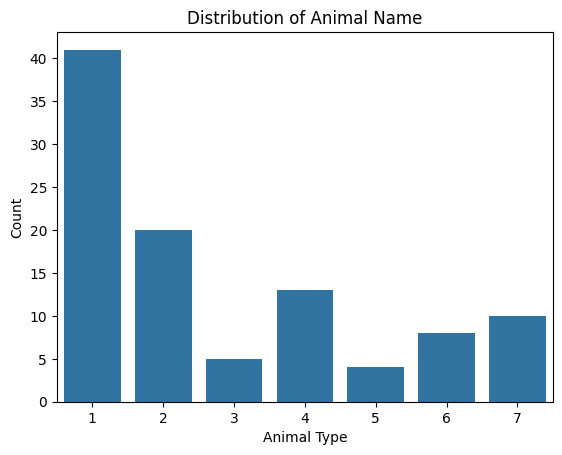

In [11]:
## Lets check the target column ditribution..
sns.countplot(x = 'type', data = df)
plt.title('Distribution of Animal Name')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.show()

In [12]:
## The count plot shows that the animal classes are not equally distributed..
## Some animal types contain more observations than other, indicating that the dataset is imbalanced.. 
## This imbalance should be considered while evaluating the KNN model since it may perfor better on majority  classes..

In [13]:
## Features vs Target (type)..

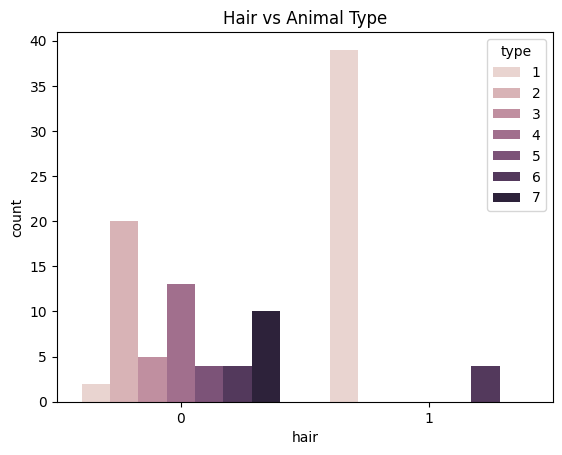

In [14]:
## Hair vs type..
sns.countplot(x = 'hair', hue = 'type', data = df)
plt.title('Hair vs Animal Type')
plt.show()

In [15]:
## Above visualization indicates that the presence of hair is associated with only certain animal types (type 1 and type 6), while many other types do not have hairs..
## Therefore, the hair feature appears too be an important charateristic for distinguishing between different animal classes.. 

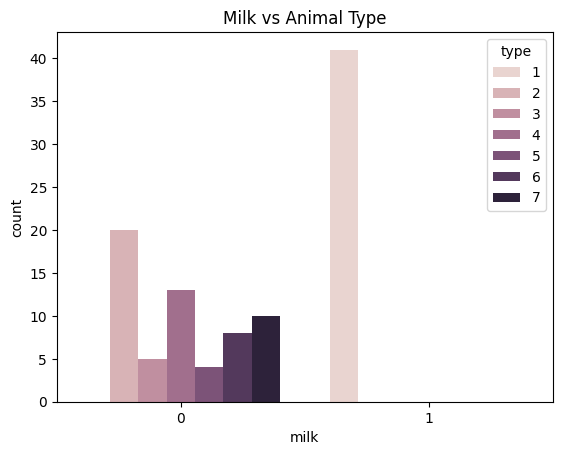

In [16]:
## milk vs type.. 
sns.countplot(x = 'milk', hue = 'type', data = df)
plt.title('Milk vs Animal Type')
plt.show()

In [17]:
## The above plot shows that only specific animal type produce milk (type 1)..
## Most other types do not produce milk.. this makes the milk feature a strong indicator for classification and helps seperate mammals from other animal groups.. 

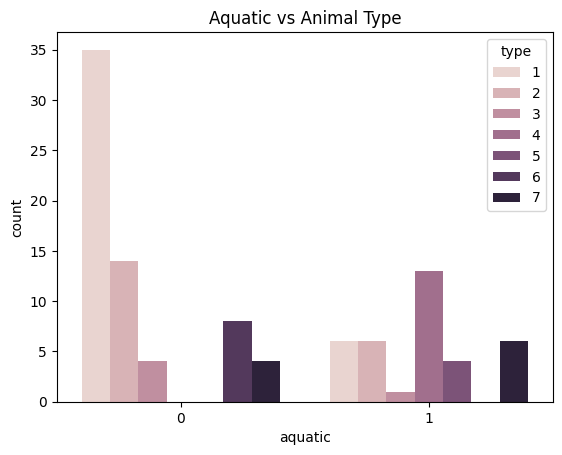

In [18]:
## aquatic vs type
sns.countplot(x = 'aquatic', hue = 'type', data = df)
plt.title('Aquatic vs Animal Type')
plt.show()

In [19]:
## The visualization shows that the aquatic feature varies across different animal types..
## Some classes contain many aquatic animals, while other consists mainly of non aquatic animals.. 
## Major part of type 1 animals are non aquatic..  
## Hence this feature contribute usefull infornation as well..

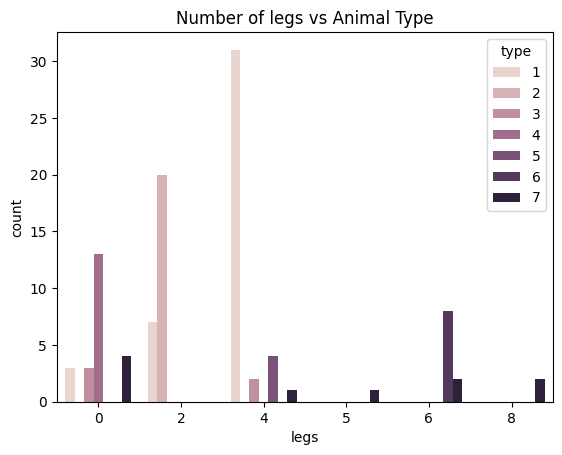

In [20]:
## legs vs type
sns.countplot(x = 'legs', hue = 'type', data = df)
plt.title('Number of legs vs Animal Type')
plt.show()

In [21]:
## The number of legs differ among animal types with value such as 0,2,4,5,6 and 8..
## Different classes tend to have different leg counts making this feature useful for distinguishing between animal categories.. 

In [22]:
## Although all the features were explored during the analysis but only hair, milk, aquatic and legs were presented..
## Because they are among the most meaningful and easily interpretable characteristics for distinguishing..
## The remaining features showed similar patterns and did not provide substantially different animal types..
## Therefore to keep the analysis concise and avoid repetative visualisation only these representatives features were included in the notebook..


Column: hair
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: feathers
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 20
****************************************************************************************************

Column: eggs
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: milk
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: airborne
Q1 : 0.0
Q3 : 0.0
IQR : 0.

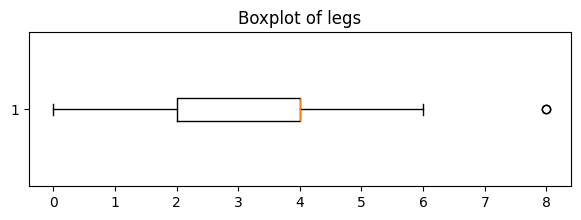

****************************************************************************************************

Column: tail
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: domestic
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 13
****************************************************************************************************

Column: catsize
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 0
****************************************************************************************************

Column: type
Q1 : 1.0
Q3 : 4.0
IQR : 3.0
Lower Bound : -3.5
Upper Bound : 8.5
Minimum Value : 1
Maximum Value : 7
Potential Outiers : 0
*****************************************

In [23]:
for i in df.columns:
    if i != "animal name":
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        min_val = df[i].min()
        max_val = df[i].max()

        ## detect outliers..
        outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

        print(f"\nColumn: {i}")
        print(f"Q1 : {Q1}")
        print(f"Q3 : {Q3}")
        print(f"IQR : {IQR}")
        print(f"Lower Bound : {lower_bound}")
        print(f"Upper Bound : {upper_bound}")
        print(f"Minimum Value : {min_val}")
        print(f"Maximum Value : {max_val}")
        print(f"Potential Outiers : {len(outliers)}")
##        if len(outliers) > 0:
##          print("Potential Outliers:")
##          print(outliers.values)

        if i == "legs":
            plt.figure(figsize = (7, 2))
            plt.boxplot(df[i].dropna(), vert = False)
            plt.title(f"Boxplot of {i}")
            plt.show()
        print("*"*100)

In [24]:
## Most features are binary variables and legs feature contain valid categorical values (0,2,4,5,6,8) 
## No abnormal outliers requiring treatment were observed.. 

In [25]:
## Correlation analysis was not included because most of the feature in the dataset are binary (0 and 1).. 
## While the target variable "type" is a categorical in integer form with multiple class, just labels.. 
## In such cases correlation values do not provide meaningful insights for classification.. 
## Since the objective of this assignment is to analyze the data using visualization and build a KNN classifier, feature wise visual analysis was considered more appropriate than correlation analysis..
## Therefore correlation analysis was excluded to avoid unnecessary and less informative results..

### 2. Preprocess the data by handling missing values & Outliers, if any.

In [26]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [27]:
## Missing value handling: 
## The dataset was checked for missing values using df.isnull().sum()
## No missing values were found in any of the columns..
## Therefore no imputation or removal of the records was required and the dataset can be ysed as it is.. 

In [28]:
## Outlier handling: 
## We already checked via box-plot and IQR and no serious outliers were detected..
## Also, since most of the features are binary variables and the legs feature contain valid categorical values (labels), so abnormal outliers requiring treatment were identified..
## Therefore no outliers handeling technique was applied.. 

In [29]:
## Lets remove unnecessary column, "animal name"
## Because it is an identifier and does not help the KNN algorithm learn any kind of pattern.. 

In [30]:
## Lets have a look at the different animals names in the animal name columns..
print(df["animal name"].tolist())

['aardvark', 'antelope', 'bass', 'bear', 'boar', 'buffalo', 'calf', 'carp', 'catfish', 'cavy', 'cheetah', 'chicken', 'chub', 'clam', 'crab', 'crayfish', 'crow', 'deer', 'dogfish', 'dolphin', 'dove', 'duck', 'elephant', 'flamingo', 'flea', 'frog', 'frog', 'fruitbat', 'giraffe', 'girl', 'gnat', 'goat', 'gorilla', 'gull', 'haddock', 'hamster', 'hare', 'hawk', 'herring', 'honeybee', 'housefly', 'kiwi', 'ladybird', 'lark', 'leopard', 'lion', 'lobster', 'lynx', 'mink', 'mole', 'mongoose', 'moth', 'newt', 'octopus', 'opossum', 'oryx', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'pike', 'piranha', 'pitviper', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'rhea', 'scorpion', 'seahorse', 'seal', 'sealion', 'seasnake', 'seawasp', 'skimmer', 'skua', 'slowworm', 'slug', 'sole', 'sparrow', 'squirrel', 'starfish', 'stingray', 'swan', 'termite', 'toad', 'tortoise', 'tuatara', 'tuna', 'vampire', 'vole', 'vulture', 'wallaby', 'wasp', 'wolf', 'worm', 'wren']


In [31]:
## Machine learning models like KNN rely on numerical features to identify patterns and the name of the animal does not represent any measurable  characteristic..
## Therefore it does not contribute to the classification of animal types and is excluded from the analysis..

df= df.drop(columns = ["animal name"])
df.columns

## also
## df = df.drop("animal name", axis = 1) or
## df.drop("animal name", axis = 1, inplace = True)

Index(['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator',
       'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail',
       'domestic', 'catsize', 'type'],
      dtype='object')

In [32]:
## Lets seperate Features and Target..
X = df.drop("type", axis = 1)
Y = df["type"]

In [33]:
## The dataset was divided into independent variables (X) and teh target variables (Y)..
## All the predictor features were assigned to X ..
## The type column was selected as the target variable for animal classification.. 

### 3. Split the dataset into training and testing sets (80% training, 20% testing).

In [34]:
## To evaluate the performance of the KNN classifier on unseen data, the dataset will be divided into training and testing sets..
## The training set (80%) will be used to train the model, while testing set (20%) is reserved for evaluting its performance ..
## Splitting the data before feature scaling also helps prevents data leakage and ensures a fair evaluation of the model.. 

In [35]:
from sklearn.model_selection import train_test_split 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 42, stratify = Y)

## stratify = Y ysed because the target has multiple classes and some classes have fewer sample..
## It will help maitain approximately the same class distribution in both training and testing sets.. 

In [36]:
## The dataset had been successfully divided into training and testing sets using an 80:20 ratio.. 
## The split was performed before fetaure scaling to avoid data leakage  and ensure a reliable evaluation.. 

In [37]:
## Feature scaling..
## There is no explicit mention about scaling in the assignment.. 
## However since the KNN algorithm is based on the distance calculation, feature scaling is considered as the best practice..
## In this dataset most of the features are binary (same scale) and the legs feature has multiple values/ labels..
## Without scaling features with larger numerical values may have greater influence on the distance calculation.. 
## Therefore standard scaler would be applied.. 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
## fit_transform() was applied to X_train_scaled because the scaler should learn the mean and standard deviation from the training data only.. 
## fit_transform() was not used on X_test_scaled because it would calculate a new mean and standard deviation from the test data..
## It would have made it scaled differently from the training data..
## Instead, transform() was used so that the test data is scaled using the same parameters learned from the training data.. 
## This also ensures consistency and prevent data leakage, allowing the model to be evaluated fairly on unseen data..

### 4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset

In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
knn = KNeighborsClassifier()
## It will create classifier using default parameters.. n_neighbour = 5, metric = "minkowski" (which becomes Euclidean distance when p = 2)

In [41]:
## Train the model..
knn.fit(X_train_scaled,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [42]:
## The KNN classifier was successfully trained using the scaled training data..
## During training, the algorithm stores the training observations and their corresponding class labels.. 
## Unlike many other Machine learning algorithms, KNN does not build an explicit mathematical model but makes predictions  based on the nearest neighbour of a new observation..

### 5. Choose an appropriate distance metric and value for K.

In [43]:
## Selection of distance metric and K:
## The performance of the KNN algorithm depends on the choice of the distance metric and the value of K (number of nearest neighbours)..
## Instead of selecting an arbitrary value, let evaluate different values of K and the one producing the highest accuracy on the testing set will be finalised..
## The default metric used is Minkowski distance (p = 2) which is equivalent to Euclidean distance and is suitable for this dataset after feature scaling.. 

In [44]:
from sklearn.metrics import accuracy_score

accuracy = []

for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled, Y_train)
    Y_pred = knn.predict(X_test_scaled)
    accuracy.append(accuracy_score(Y_test, Y_pred))

best_k = accuracy.index(max(accuracy)) + 1

print("Best K:", best_k)
print("Highest Accuracy:", max(accuracy))

Best K: 1
Highest Accuracy: 1.0


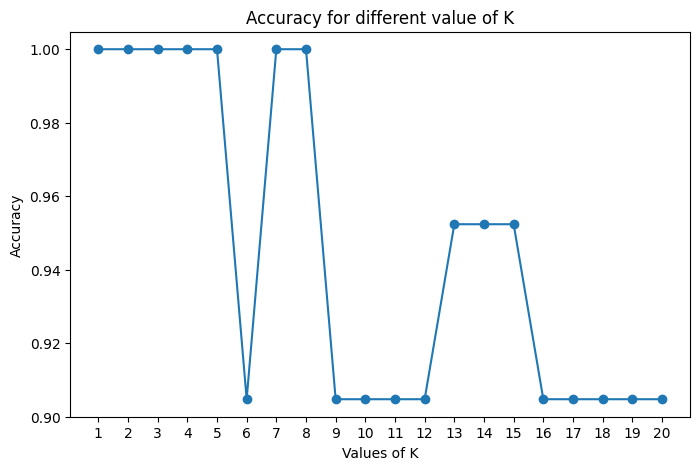

In [45]:
## Lets visualize Accuracy vs K
plt.figure(figsize = (8, 5))
plt.plot(range(1, 21), accuracy, marker = "o")
plt.title("Accuracy for different value of K")
plt.xlabel("Values of K")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.show()

In [46]:
## The highest accuracy of 100% is achieved when K = 1,2,3,4,5,7 and 8..
## The accuracy drops to about 90.5% for K = 6 and k = 9-12 .. increase sclightly to around 95.5% for K = 13-15..
## Again decreases to about 90.5% for K = 16-20.. 
## Since several values of K gives the maximum accuracy, the smallest odd value, K = 3, should be an appropriate choice..
## Because it provides excellent performance while reducing the chance of ties in classification.. 

In [47]:
## Lets build the final model using best K ..
## We decided best K as 3
knn_final = KNeighborsClassifier(n_neighbors = 3)
knn_final.fit(X_train_scaled, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
## Prediction..
Y_pred_final = knn_final.predict(X_test_scaled)

### 6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.

In [49]:
from sklearn.metrics import classification_report

## Classification report will have all of the report (accuracy, precision, recall, and F1-score metrics)

In [50]:
## Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred_final))

Accuracy: 1.0


In [51]:
## Classification report..
print(classification_report(Y_test, Y_pred_final))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [52]:
## The KNN classifier achieved an accuracy of 100% on the test dataset, indicating that all test instances were classifiued correctly..
## The precision, recall, F1-score are also 1.00 for every animal type, showing that the models made no misclassifications and was able to correctly identify every class in the test set..
## The macro average and weighted average of precision, recall and F1-score are all 1.00, confirming that the model performed consistently across all classes.. 
## Therefore the selected value of K = 3 and the chose distance metric were appropriate for this dataset resulting and excellent classification performance..

In [53]:
## The model achieved an accuracy of 100% on the test dataset.. 
## This result is reasonable because the dataset is relatively small and the animal classes are well distinguished by their characterics such as hair, feathers, milk, aquatic nature etc..
## The data was also properly preprocessed by splitting it into training and testing sets before scaling..
## And the scaler was only fitted on the training data to avoid lekage..

### 7. Visualize the decision boundaries of the classifier.

In [54]:
## The KNN model was trained using multiple input features, making it impossible to visualize its decision boundary directly in two dimensions..
## Therefore PCA has to be applied just for this step to reduce thefeature space to two principle component..
## This step is only performed for visualization purpose and will not effect the previously trained KNN final model or its results..

In [55]:
## Apply PCA 
from  sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [56]:
## Train KNN on PCA data..
knn_pca = KNeighborsClassifier(n_neighbors = 3)
knn_pca.fit(X_train_pca,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


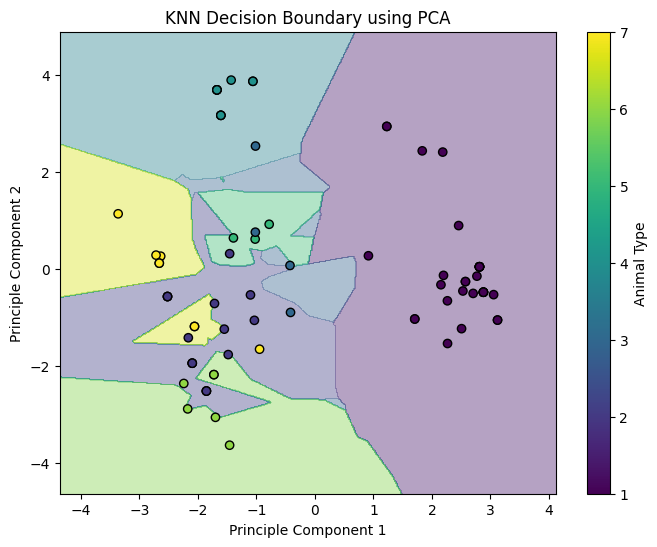

In [57]:
## plot decision boundary..
import numpy as np
X_min, X_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
Y_min, Y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(X_min, X_max, 0.02), np.arange(Y_min, Y_max, 0.02))

Z = knn_pca.predict(np.c_[XX.ravel(), YY.ravel()])
Z = Z.reshape(XX.shape)

plt.figure(figsize = (8, 6))
plt.contourf(XX, YY, Z, alpha = 0.4)

plt.scatter(X_train_pca[:, 0],
           X_train_pca[:, 1], 
           c = Y_train, cmap = "viridis",
           edgecolors = "k")
plt.colorbar(label = "Animal Type")

plt.title("KNN Decision Boundary using PCA")
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()

In [58]:
## The decision boundary plot shows how the KNN classifier divides the feature space into different animal classes after reducing the data to two dimensions using PCA..
## Each colored region represents the class predicted by the model, while the dots represent the training observations..
## Most data points lie within their corresponding decision region, indicating that the classifier is able to seperate the animal types effectively..
## The presence of multiple irregular boundaries is expected in KNN as the algorithm classifies observations based on the nearest neighbour points rather that fitting a linear bourdary..
## PCA was used only to enable visualization and does not affect the performancxe of original KNN model model.. 

## A few points appear to lie outside their  corresponding decision regions..
## This is expected because PCA reduces the original high-dimensional data to only two dimensions for visualizations,causing some overlap between classes..
## The actual KNN model was trained on all features and therefore achieved better classification.. 

In [59]:
## Conclusion:
## The KNN algorithm was successfully implemented for classifying animal types.. 
## The dataset was analysed, preprocessed by checking missing values and outliers, and standardized before model building..
## An 80:20 train-test split was used and different values of K were evaluated to select the most appropriate one..
## The final KNN model achieved 100% accuracy along with excellent precision, recall and F1-score, indicating that it classified the animal types effectively.. 
## A decision boundary was also visualized using PCA to understand how the classifier seperates different lasses in a two-dimensional space.. 

### Interview Questions:

#### 1. What are the key hyperparameters in KNN?

In [60]:
## The key hyperparameters in KNN are:

## Numbers of Neighbours (K): Determines how many nearest neighbours are considered for prediction. It is the most mportant hyperparameter..
## Distance Metric: Defines how the distance between data points is calculated (eg. Euclidean, Manhattan)..
## Weights: Specifies whether all neighbours have equal importance (uniform) or closer neighbour are given more importance (distance)..
## Algorithm: Determines the method used to search for nearest neighbours such as auto, ball_tree, kd_tree or brute.. 
## Leaf Size: Controls the speed and memory usage for tree-based search algorithms.. 

#### 2. What distance metrics can be used in KNN?

In [61]:
## Common Distance metric used in KNN are:

## Euclidean Distance: Straight-line distance between two points, the most commonly used metric..
## Manhattan Distance: Calculates distance by summing the absolute difference between coordinates..
## Minkowski Distance: A geeralized distance metric that includes Euclidean and Manhattan distances as special cases..
## Chebyshev Distance: Uses the maximum absolute difference between coordinates.. 
## Hamming Distance: Suitable for comparing binary or categorical data..  